# Test 07: Scale law для коэффициентов активации

**Цель:** Найти эмпирический закон вида $a^* = c / \sigma^\gamma$, объединяющий наблюдения тестов 22-23 в единую формулу. Идентифицировать **управляющую переменную** для оптимального $a$.

**Что проверяем:**

1. **Управляющая переменная.** Какая величина определяет оптимальный $a^*$?
   - $\sigma_{eff}^{(input)}$ — std входов после скейлинга
   - $\sigma_{eff}^{(post\text{-}Dense)}$ — std предактиваций $Wx+b$ после обучения
   - Intrinsic dim — эффективный ранг через PCA
   - Kurtosis активаций
2. **Закон масштаба.** Линейность в log-log координатах: $\log a^* = \log c - \gamma \log \sigma$
3. **Качество подгонки.** $R^2$ + bootstrap confidence intervals для $\gamma, c$

**Методология:**

1. Фиксированный домен: GPT-2 layer 6 normalized (один источник данных)
2. Контролируемая вариация: input scale $s \in \{0.25, 0.5, 1, 2, 4\}$
3. Для каждого $s$: sweep по $a \in \{0.25, 0.5, 1, 2, 4, 8\}$
4. Для каждой $(s, a)$ конфигурации: 2 seed (минимум для статистики)
5. Финал: найти $a^*(s) = \text{argmin}_a \text{val\_loss}$, построить scale law

**Decision tree:**

- $R^2 > 0.9$ для какой-то переменной → scale law найден, добавляем в proof.md
- $0.7 < R^2 < 0.9$ → noisy law, нужны больше seeds или wider grid
- $R^2 < 0.7$ для всех candidates → закон не найден, документируем как negative result

**Время прогона на A100:** ~5-7 часов (60 runs × ~5 мин + analysis).

**Compute units:** ~30-40 из 600 (Colab Pro+).

## 1. Установка и подключение Drive

In [ ]:
!pip install -q transformers datasets

In [ ]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import json
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from google.colab import drive
drive.mount('/content/drive')

PROTO_DIR = Path('/content/drive/MyDrive/chaos_compressor')
CACHE_DIR = PROTO_DIR / 'cache'
JSONS_DIR = PROTO_DIR / 'jsons'
RESULTS_DIR = PROTO_DIR / 'scale_law_results'
DATA_DIR = Path('/content/data')

PROTO_DIR.mkdir(exist_ok=True, parents=True)
CACHE_DIR.mkdir(exist_ok=True)
JSONS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print(f'Drive: {PROTO_DIR}')

Mounted at /content/drive
Drive: /content/drive/MyDrive/chaos_compressor


## 2. Подготовка данных

Загружаем активации GPT-2 layer 6 (или из кэша, или экстрактим), нормализуем, сохраняем в локальный fast scratch для subprocess'ов.

In [ ]:
ACTIVATION_DIM = 768
TARGET_LAYER = 6
N_TEXTS = 500

cache_file = CACHE_DIR / f'gpt2_layer{TARGET_LAYER}_n{N_TEXTS}.npy'

if cache_file.exists():
    print(f'Загрузка из кэша: {cache_file}')
    activations = np.load(cache_file)
else:
    print('Извлекаем активации из GPT-2...')
    import torch
    from transformers import GPT2Model, GPT2Tokenizer
    from datasets import load_dataset

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    model = GPT2Model.from_pretrained('gpt2'); model.eval()
    tokenizer.pad_token = tokenizer.eos_token
    dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    texts = [t for t in dataset['text'] if len(t) > 100][:N_TEXTS]

    acts = []
    with torch.no_grad():
        for i, text in enumerate(texts):
            inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
            out = model(**inputs, output_hidden_states=True)
            h = out.hidden_states[TARGET_LAYER].squeeze(0).numpy()
            acts.append(h)
            if (i + 1) % 100 == 0: print(f'  {i+1}/{len(texts)}')
    activations = np.concatenate(acts, axis=0).astype('float32')
    np.save(cache_file, activations)
    del model, tokenizer

act_mean = activations.mean(axis=0, keepdims=True)
act_std = activations.std(axis=0, keepdims=True) + 1e-8
activations_norm = ((activations - act_mean) / act_std).astype('float32')

np.random.seed(42)
idx = np.random.permutation(len(activations_norm))
split = int(len(idx) * 0.8)
x_train = activations_norm[idx[:split]]
x_test = activations_norm[idx[split:]]

np.save(DATA_DIR / 'x_train.npy', x_train)
np.save(DATA_DIR / 'x_test.npy', x_test)

print(f'Train: {x_train.shape}, Test: {x_test.shape}')

Загрузка из кэша: /content/drive/MyDrive/chaos_compressor/cache/gpt2_layer6_n500.npy
Train: (43658, 768), Test: (10915, 768)


## 3. Worker-скрипт для subprocess

Каждый запуск в изолированном процессе для чистой памяти. Worker тренирует одну SAE при заданном `(input_scale, a, seed)` и возвращает:

- `val_loss` — для определения $a^*(s)$
- `sigma_eff_input` — std входов после скейлинга
- `sigma_eff_post_dense` — std предактиваций $Wx+b$ после обучения
- `intrinsic_dim` — эффективный ранг (число компонент для 99% дисперсии)
- `kurtosis` — эксцесс активаций

In [ ]:
%%writefile /content/scale_law_worker.py
"""Worker для одной тренировки в scale law sweep."""
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
import json
import argparse
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy import stats as sp_stats


def chaos_activation(x, a=1.0, w=0.5, b=4.0):
    return tf.sin(a * x) + w * tf.tanh(b * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k
    def call(self, inputs):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask


class ChaosActivation(layers.Layer):
    """Активация с настраиваемыми параметрами a, w, b."""
    def __init__(self, a=1.0, w=0.5, b=4.0, **kwargs):
        super().__init__(**kwargs)
        self.a = a; self.w = w; self.b = b
    def call(self, x):
        return chaos_activation(x, self.a, self.w, self.b)


def build_sae(input_dim, latent_dim, k_active, a, w=0.5, b=4.0):
    inp = keras.Input(shape=(input_dim,))
    pre = layers.Dense(latent_dim, name='latent_pre')(inp)
    act = ChaosActivation(a=a, w=w, b=b, name='chaos_act')(pre)
    z = KSparseLayer(k=k_active, name='latent_ksparse')(act)
    enc = keras.Model(inp, z, name='encoder')
    pre_model = keras.Model(inp, pre, name='pre_model')
    decoded = layers.Dense(input_dim, name='decoder')(z)
    ae = keras.Model(inp, decoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, pre_model


def measure_intrinsic_dim(activations, var_threshold=0.99):
    """Эффективный ранг: число PCA компонент для 99% дисперсии."""
    sample = activations[:5000] if len(activations) > 5000 else activations
    sample = sample - sample.mean(axis=0, keepdims=True)
    try:
        u, s, vt = np.linalg.svd(sample, full_matrices=False)
        var_explained = (s ** 2) / (s ** 2).sum()
        cumvar = np.cumsum(var_explained)
        n_components = int(np.searchsorted(cumvar, var_threshold) + 1)
        return n_components
    except Exception:
        return -1


def measure_metrics(ae, enc, pre_model, x_test, input_scale):
    """Все измерения для scale law analysis."""
    x_scaled = x_test * input_scale
    sigma_input = float(np.std(x_scaled, axis=0).mean())

    pre_acts = pre_model.predict(x_scaled, batch_size=256, verbose=0)
    sigma_post_dense = float(np.std(pre_acts, axis=0).mean())

    latents = enc.predict(x_scaled, batch_size=256, verbose=0)
    nonzero = latents[np.abs(latents) > 1e-10]
    kurt = float(sp_stats.kurtosis(nonzero)) if nonzero.size > 0 else 0.0

    intrinsic_dim_pre = measure_intrinsic_dim(pre_acts)
    intrinsic_dim_lat = measure_intrinsic_dim(latents)

    dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
    lat_var = float(latents.var())
    lat_range = [float(nonzero.min()), float(nonzero.max())] if nonzero.size > 0 else [0.0, 0.0]

    return {
        'sigma_eff_input': sigma_input,
        'sigma_eff_post_dense': sigma_post_dense,
        'kurtosis': kurt,
        'intrinsic_dim_pre': intrinsic_dim_pre,
        'intrinsic_dim_lat': intrinsic_dim_lat,
        'dead_latents': dead,
        'lat_var': lat_var,
        'lat_range': lat_range,
    }


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--input_scale', type=float, required=True)
    parser.add_argument('--a', type=float, required=True)
    parser.add_argument('--seed', type=int, required=True)
    parser.add_argument('--epochs', type=int, default=8)
    parser.add_argument('--batch', type=int, default=256)
    parser.add_argument('--data_dir', type=str, required=True)
    parser.add_argument('--output', type=str, required=True)
    args = parser.parse_args()

    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for g in gpus:
            try: tf.config.experimental.set_memory_growth(g, True)
            except RuntimeError: pass

    x_train_raw = np.load(f'{args.data_dir}/x_train.npy')
    x_test_raw = np.load(f'{args.data_dir}/x_test.npy')

    x_train = x_train_raw * args.input_scale
    x_test = x_test_raw * args.input_scale

    np.random.seed(args.seed)
    tf.random.set_seed(args.seed)

    INPUT_DIM = 768
    LATENT_DIM = 3072
    K_ACTIVE = 307

    ae, enc, pre_model = build_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, a=args.a, w=0.5, b=4.0)
    hist = ae.fit(x_train, x_train, epochs=args.epochs, batch_size=args.batch,
                   validation_data=(x_test, x_test), verbose=0)
    val_loss = float(hist.history['val_loss'][-1])

    metrics = measure_metrics(ae, enc, pre_model, x_test_raw, args.input_scale)

    result = {
        'input_scale': args.input_scale,
        'a': args.a,
        'seed': args.seed,
        'val_loss': val_loss,
        **metrics,
    }
    with open(args.output, 'w') as f:
        json.dump(result, f, default=float)
    print(f'  scale={args.input_scale} a={args.a} seed={args.seed} '
          f'loss={val_loss:.4f} sigma_in={metrics["sigma_eff_input"]:.3f} '
          f'sigma_post={metrics["sigma_eff_post_dense"]:.3f} '
          f'kurt={metrics["kurtosis"]:.2f} idim_pre={metrics["intrinsic_dim_pre"]} '
          f'dead={metrics["dead_latents"]}', flush=True)


if __name__ == '__main__':
    main()

Writing /content/scale_law_worker.py


## 4. Конфигурация эксперимента

In [ ]:
INPUT_SCALES = [0.25, 0.5, 1.0, 2.0, 4.0]
A_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
SEEDS = [42, 43]
EPOCHS = 8
BATCH = 256

total_runs = len(INPUT_SCALES) * len(A_VALUES) * len(SEEDS)
print(f'Input scales: {INPUT_SCALES}')
print(f'A values: {A_VALUES}')
print(f'Seeds: {SEEDS}')
print(f'Total runs: {total_runs}')

Input scales: [0.25, 0.5, 1.0, 2.0, 4.0]
A values: [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
Seeds: [42, 43]
Total runs: 60


## 5. Главный цикл — subprocess с auto-resume

Каждая тренировка в отдельном процессе для гарантированной чистой памяти.

In [10]:
ts_start = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Start: {ts_start}')
print(f'Results dir: {RESULTS_DIR}\n')

completed = 0
skipped = 0
failed = []

for input_scale in INPUT_SCALES:
    print(f'\n=== input_scale = {input_scale} ===')
    for a_val in A_VALUES:
        for seed in SEEDS:
            tag = f's{input_scale}_a{a_val}_seed{seed}'
            output_file = RESULTS_DIR / f'{tag}.json'

            if output_file.exists():
                print(f'  [skip] {tag} (уже есть)')
                skipped += 1
                continue

            cmd = [
                'python', '/content/scale_law_worker.py',
                '--input_scale', str(input_scale),
                '--a', str(a_val),
                '--seed', str(seed),
                '--epochs', str(EPOCHS),
                '--batch', str(BATCH),
                '--data_dir', str(DATA_DIR),
                '--output', str(output_file),
            ]
            try:
                result = subprocess.run(cmd, capture_output=True, text=True, timeout=1200)
                if result.returncode == 0:
                    if result.stdout.strip():
                        print(result.stdout.strip())
                    completed += 1
                else:
                    print(f'  [FAILED] {tag}: returncode={result.returncode}')
                    print(f'  stderr: {result.stderr[-500:]}')
                    failed.append(tag)
            except subprocess.TimeoutExpired:
                print(f'  [TIMEOUT] {tag}')
                failed.append(tag)
            except Exception as e:
                print(f'  [ERROR] {tag}: {e}')
                failed.append(tag)

print(f'\nЗавершено: {completed} новых, {skipped} пропущено, {len(failed)} упало')
if failed:
    print(f'Failed: {failed}')

Start: 20260504_092853
Results dir: /content/drive/MyDrive/chaos_compressor/scale_law_results


=== input_scale = 0.25 ===
scale=0.25 a=0.25 seed=42 loss=0.0093 sigma_in=0.250 sigma_post=0.068 kurt=-1.38 idim_pre=708 dead=0
scale=0.25 a=0.25 seed=43 loss=0.0092 sigma_in=0.250 sigma_post=0.068 kurt=-1.39 idim_pre=708 dead=0
scale=0.25 a=0.5 seed=42 loss=0.0091 sigma_in=0.250 sigma_post=0.065 kurt=-1.19 idim_pre=709 dead=0
scale=0.25 a=0.5 seed=43 loss=0.0091 sigma_in=0.250 sigma_post=0.066 kurt=-1.19 idim_pre=709 dead=0
scale=0.25 a=1.0 seed=42 loss=0.0091 sigma_in=0.250 sigma_post=0.060 kurt=-0.91 idim_pre=711 dead=0
scale=0.25 a=1.0 seed=43 loss=0.0090 sigma_in=0.250 sigma_post=0.060 kurt=-0.90 idim_pre=711 dead=0
scale=0.25 a=2.0 seed=42 loss=0.0092 sigma_in=0.250 sigma_post=0.051 kurt=-0.74 idim_pre=713 dead=0
scale=0.25 a=2.0 seed=43 loss=0.0092 sigma_in=0.250 sigma_post=0.051 kurt=-0.75 idim_pre=713 dead=0
scale=0.25 a=4.0 seed=42 loss=0.0098 sigma_in=0.250 sigma_post=0.042 kurt=-

## 6. Сборка результатов и определение $a^*(s)$ для каждого scale

In [11]:
# === Загрузка всех результатов ===

results = []
for json_file in sorted(RESULTS_DIR.glob('*.json')):
    with open(json_file) as f:
        results.append(json.load(f))

print(f'Загружено {len(results)} результатов')

# === Aggregation: для каждого (input_scale, a) усредняем по seeds ===

def agg_by_config(input_scale, a_val):
    runs = [r for r in results if abs(r['input_scale'] - input_scale) < 1e-6
             and abs(r['a'] - a_val) < 1e-6]
    if not runs:
        return None
    return {
        'input_scale': input_scale,
        'a': a_val,
        'val_loss_mean': float(np.mean([r['val_loss'] for r in runs])),
        'val_loss_std': float(np.std([r['val_loss'] for r in runs])),
        'sigma_eff_input': float(np.mean([r['sigma_eff_input'] for r in runs])),
        'sigma_eff_post_dense': float(np.mean([r['sigma_eff_post_dense'] for r in runs])),
        'kurtosis': float(np.mean([r['kurtosis'] for r in runs])),
        'intrinsic_dim_pre': float(np.mean([r['intrinsic_dim_pre'] for r in runs])),
        'dead_latents': float(np.mean([r['dead_latents'] for r in runs])),
        'n_runs': len(runs),
    }

agg_data = []
for s in INPUT_SCALES:
    for a in A_VALUES:
        d = agg_by_config(s, a)
        if d is not None:
            agg_data.append(d)

# === Для каждого input_scale находим a*(s) = argmin loss ===

best_per_scale = {}
for s in INPUT_SCALES:
    rows = [d for d in agg_data if abs(d['input_scale'] - s) < 1e-6]
    if not rows: continue
    best_row = min(rows, key=lambda r: r['val_loss_mean'])
    best_per_scale[s] = best_row

print('\nОптимальное a* для каждого input_scale:')
print(f'{"scale":>8} {"a*":>6} {"loss":>10} {"σ_input":>10} {"σ_post":>10} {"kurt":>8} {"i_dim":>8}')
print('-' * 70)
for s, d in sorted(best_per_scale.items()):
    print(f'{s:>8.2f} {d["a"]:>6.2f} {d["val_loss_mean"]:>10.4f} '
          f'{d["sigma_eff_input"]:>10.3f} {d["sigma_eff_post_dense"]:>10.3f} '
          f'{d["kurtosis"]:>8.2f} {d["intrinsic_dim_pre"]:>8.0f}')

Загружено 60 результатов

Оптимальное a* для каждого input_scale:
   scale     a*       loss    σ_input     σ_post     kurt    i_dim
----------------------------------------------------------------------
    0.25   1.00     0.0091      0.250      0.060    -0.90      711
    0.50   1.00     0.0387      0.501      0.125    -1.44      702
    1.00   0.25     0.1573      1.002      0.857    -1.80      666
    2.00   0.25     0.6430      2.004      1.274    -1.86      686
    4.00   0.25     3.2003      4.008      1.900    -1.92      666


## 7. Loss surfaces — sanity check

Перед fit'ом scale law убеждаемся что минимум $a^*$ найден корректно (не на границе grid'а).

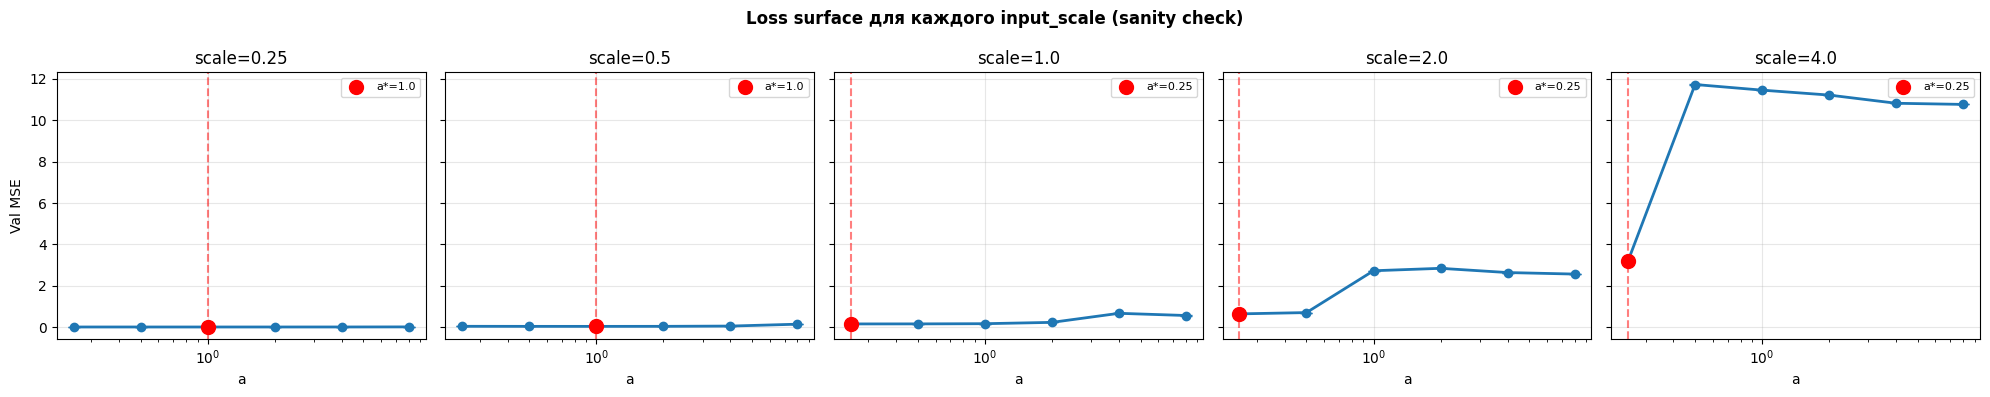

⚠️ scale=1.0: a*=0.25 на границе grid — расширьте A_VALUES
⚠️ scale=2.0: a*=0.25 на границе grid — расширьте A_VALUES
⚠️ scale=4.0: a*=0.25 на границе grid — расширьте A_VALUES


In [12]:
fig, axes = plt.subplots(1, len(INPUT_SCALES), figsize=(4 * len(INPUT_SCALES), 4), sharey=True)

for ax, s in zip(axes, INPUT_SCALES):
    rows = sorted([d for d in agg_data if abs(d['input_scale'] - s) < 1e-6],
                   key=lambda r: r['a'])
    if not rows: continue
    a_vals = [r['a'] for r in rows]
    losses = [r['val_loss_mean'] for r in rows]
    stds = [r['val_loss_std'] for r in rows]
    ax.errorbar(a_vals, losses, yerr=stds, marker='o', capsize=4, linewidth=2)

    a_star = best_per_scale[s]['a']
    a_star_loss = best_per_scale[s]['val_loss_mean']
    ax.axvline(x=a_star, color='red', linestyle='--', alpha=0.5)
    ax.scatter([a_star], [a_star_loss], color='red', s=100, zorder=5, label=f'a*={a_star}')

    ax.set_xscale('log')
    ax.set_xlabel('a')
    if ax is axes[0]: ax.set_ylabel('Val MSE')
    ax.set_title(f'scale={s}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Loss surface для каждого input_scale (sanity check)', fontweight='bold')
plt.tight_layout()
plt.savefig(PROTO_DIR / 'scale_law_loss_surfaces.png', dpi=120, bbox_inches='tight')
plt.show()

# Предупреждение если a* на границе
for s, d in best_per_scale.items():
    if d['a'] == min(A_VALUES) or d['a'] == max(A_VALUES):
        print(f'⚠️ scale={s}: a*={d["a"]} на границе grid — расширьте A_VALUES')

## 8. Scale law analysis: log-log fit для каждой candidate variable

In [14]:
# === Linear fit в log-log: log(a*) = log(c) - γ · log(σ) ===

def loglog_fit(x_values, y_values):
    """Возвращает (γ, log_c, R²) для y = c · x^(-γ)."""
    x_arr = np.array(x_values, dtype=float)
    y_arr = np.array(y_values, dtype=float)
    valid = (x_arr > 0) & (y_arr > 0)
    if valid.sum() < 3:
        return None, None, None
    log_x = np.log(x_arr[valid])
    log_y = np.log(y_arr[valid])
    # Защита от degenerate случаев (все x одинаковые или все y одинаковые)
    if np.std(log_x) < 1e-10 or np.std(log_y) < 1e-10:
        return None, None, None
    try:
        slope, intercept, r_value, p_value, std_err = sp_stats.linregress(log_x, log_y)
    except ValueError:
        return None, None, None
    gamma = -slope
    c = np.exp(intercept)
    r_squared = r_value ** 2
    return gamma, c, r_squared


def bootstrap_fit(x_values, y_values, n_bootstrap=1000, rng_seed=42):
    """Bootstrap CI для γ. Skip resamples с degenerate x."""
    x_arr = np.array(x_values, dtype=float)
    y_arr = np.array(y_values, dtype=float)
    valid = (x_arr > 0) & (y_arr > 0)
    x_arr = x_arr[valid]; y_arr = y_arr[valid]
    if len(x_arr) < 3:
        return None, None
    rng = np.random.default_rng(rng_seed)
    gammas = []
    skipped = 0
    for _ in range(n_bootstrap):
        idx = rng.choice(len(x_arr), len(x_arr), replace=True)
        x_sample = x_arr[idx]
        y_sample = y_arr[idx]
        # Skip degenerate resamples (все x одинаковые)
        if np.std(np.log(x_sample[x_sample > 0])) < 1e-10:
            skipped += 1
            continue
        gamma, _, _ = loglog_fit(x_sample, y_sample)
        if gamma is not None and np.isfinite(gamma):
            gammas.append(gamma)
    if len(gammas) < 100:
        return None, None
    return float(np.percentile(gammas, 2.5)), float(np.percentile(gammas, 97.5))


# === Извлекаем (variable, a*) пары для каждого candidate ===

candidates = ['sigma_eff_input', 'sigma_eff_post_dense', 'kurtosis', 'intrinsic_dim_pre']
candidate_labels = {
    'sigma_eff_input': r'$\sigma_{eff}^{(input)}$',
    'sigma_eff_post_dense': r'$\sigma_{eff}^{(post-Dense)}$',
    'kurtosis': 'kurtosis',
    'intrinsic_dim_pre': 'intrinsic dim',
}

fits = {}
for cand in candidates:
    x_values = [d[cand] for s, d in sorted(best_per_scale.items())]
    y_values = [d['a'] for s, d in sorted(best_per_scale.items())]
    gamma, c, r2 = loglog_fit(x_values, y_values)
    if gamma is not None:
        ci_low, ci_high = bootstrap_fit(x_values, y_values, n_bootstrap=1000)
    else:
        ci_low, ci_high = None, None
    fits[cand] = {
        'gamma': gamma, 'c': c, 'r_squared': r2,
        'ci_low': ci_low, 'ci_high': ci_high,
        'x_values': x_values, 'y_values': y_values,
    }

# === Печать результатов fits ===

print('Scale law fits для каждой candidate variable:\n')
print(f'{"Variable":<28} {"γ (slope)":>12} {"c (const)":>12} {"R²":>8} {"CI 95%":>20}')
print('-' * 85)
for cand in candidates:
    f = fits[cand]
    label = candidate_labels[cand]
    if f['gamma'] is None:
        print(f'{label:<28} insufficient data or degenerate (constant x)')
        continue
    ci_str = f'[{f["ci_low"]:.3f}, {f["ci_high"]:.3f}]' if f['ci_low'] is not None else '   -   '
    print(f'{label:<28} {f["gamma"]:>+12.3f} {f["c"]:>12.3f} '
          f'{f["r_squared"]:>8.3f} {ci_str:>20}')


Scale law fits для каждой candidate variable:

Variable                        γ (slope)    c (const)       R²               CI 95%
-------------------------------------------------------------------------------------
$\sigma_{eff}^{(input)}$           +0.600        0.436    0.750       [0.464, 1.143]
$\sigma_{eff}^{(post-Dense)}$       +0.483        0.291    0.937       [0.407, 0.660]
kurtosis                     insufficient data or degenerate (constant x)
intrinsic dim                     -22.944        0.000    0.813   [-43.700, -19.195]


## 9. Визуализация: log-log plots для каждого candidate

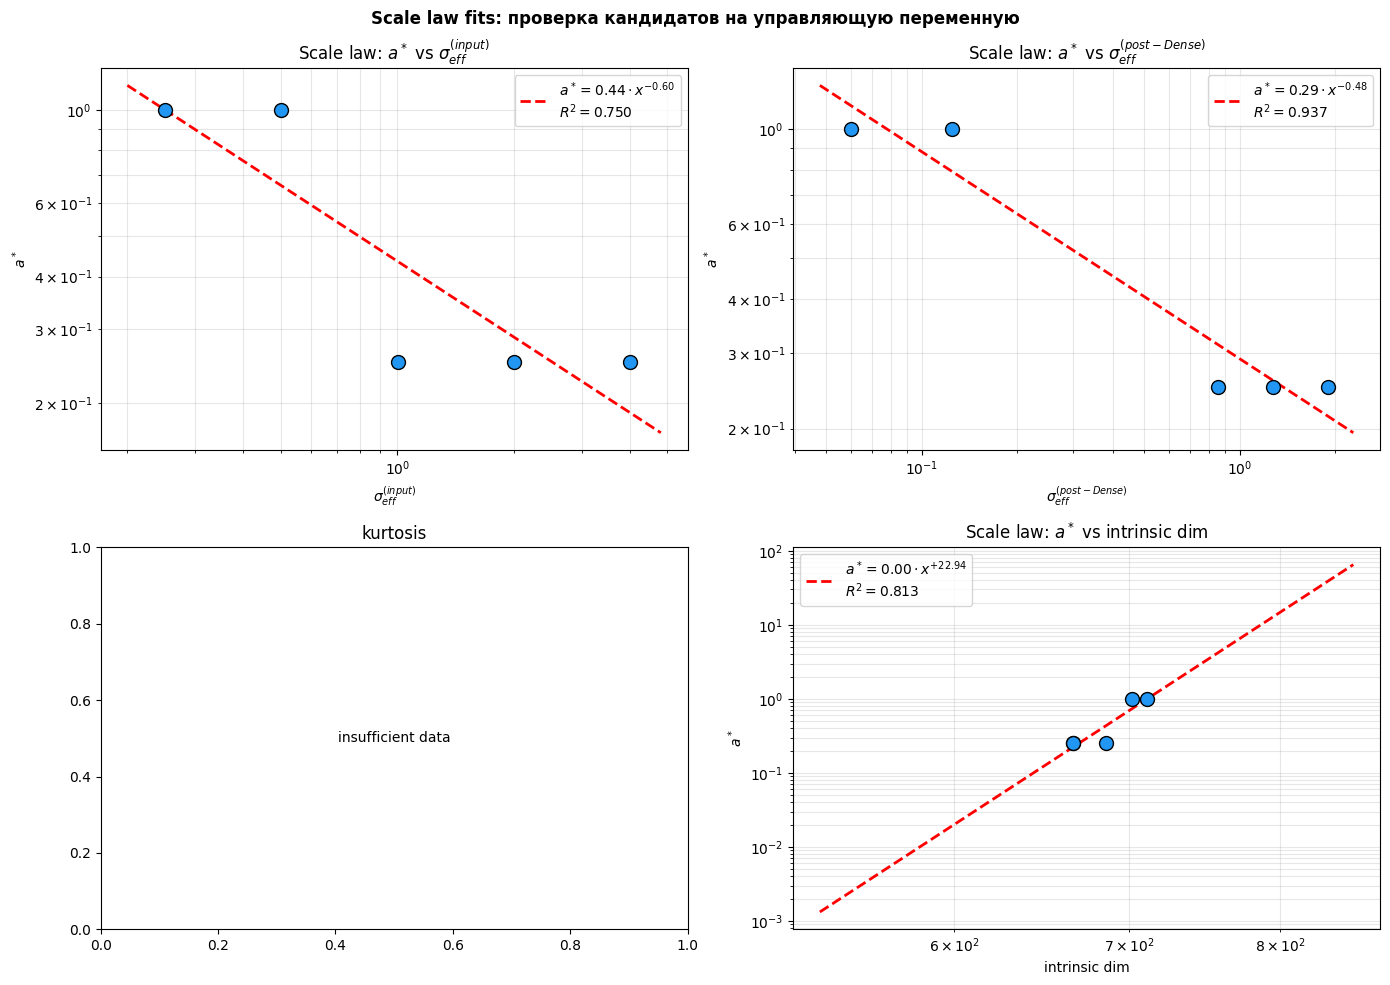

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, cand in zip(axes, candidates):
    f = fits[cand]
    if f['gamma'] is None:
        ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                 transform=ax.transAxes)
        ax.set_title(candidate_labels[cand])
        continue
    x_arr = np.array(f['x_values'])
    y_arr = np.array(f['y_values'])
    valid = (x_arr > 0) & (y_arr > 0)

    ax.scatter(x_arr[valid], y_arr[valid], s=100, color='#2196F3', edgecolor='black', zorder=5)

    x_fit = np.logspace(np.log10(x_arr[valid].min() * 0.8),
                          np.log10(x_arr[valid].max() * 1.2), 100)
    y_fit = f['c'] * x_fit ** (-f['gamma'])
    ax.plot(x_fit, y_fit, '--', color='red', linewidth=2,
             label=f'$a^* = {f["c"]:.2f} \\cdot x^{{{-f["gamma"]:+.2f}}}$\n$R^2 = {f["r_squared"]:.3f}$')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(candidate_labels[cand])
    ax.set_ylabel(r'$a^*$')
    ax.set_title(f'Scale law: $a^*$ vs {candidate_labels[cand]}')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Scale law fits: проверка кандидатов на управляющую переменную',
              fontweight='bold')
plt.tight_layout()
plt.savefig(PROTO_DIR / 'scale_law_candidates.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Decision tree: какая переменная — управляющая?

In [16]:
# === Ранжирование candidate variables по R² ===

valid_fits = [(cand, fits[cand]) for cand in candidates
                if fits[cand]['gamma'] is not None]
valid_fits.sort(key=lambda x: -x[1]['r_squared'])

print('=== Ранжирование candidate variables ===\n')
for i, (cand, f) in enumerate(valid_fits, 1):
    print(f'{i}. {candidate_labels[cand]}: R² = {f["r_squared"]:.3f}, '
          f'γ = {f["gamma"]:+.2f}')

print()

best_cand, best_f = valid_fits[0] if valid_fits else (None, None)

verdict = {}
if best_f is None:
    verdict['status'] = 'NO DATA'
    print('⚠️ Недостаточно данных для fit. Запустите больше конфигураций.')
elif best_f['r_squared'] > 0.9:
    verdict['status'] = 'SCALE LAW FOUND'
    verdict['controlling_variable'] = best_cand
    verdict['gamma'] = best_f['gamma']
    verdict['c'] = best_f['c']
    verdict['r_squared'] = best_f['r_squared']
    print(f'✅ SCALE LAW FOUND')
    print(f'   Управляющая переменная: {candidate_labels[best_cand]}')
    print(f'   Закон: a* = {best_f["c"]:.3f} · x^({-best_f["gamma"]:+.2f})')
    print(f'   R² = {best_f["r_squared"]:.3f}')
    if best_f['ci_low'] is not None:
        print(f'   95% CI для γ: [{best_f["ci_low"]:.2f}, {best_f["ci_high"]:.2f}]')
elif best_f['r_squared'] > 0.7:
    verdict['status'] = 'NOISY LAW'
    verdict['controlling_variable'] = best_cand
    verdict['r_squared'] = best_f['r_squared']
    print(f'🟡 NOISY LAW (R² = {best_f["r_squared"]:.3f})')
    print(f'   Лучший candidate: {candidate_labels[best_cand]}')
    print(f'   Рекомендация: больше seeds или wider grid по input_scale')
else:
    verdict['status'] = 'NO LAW'
    verdict['best_candidate'] = best_cand
    verdict['best_r_squared'] = best_f['r_squared']
    print(f'❌ NO LAW FOUND (best R² = {best_f["r_squared"]:.3f})')
    print('   Все candidate variables дают слабый fit.')
    print('   Возможно, управляющая переменная — другая (intrinsic dim?)')
    print('   Или a* зависит от нескольких переменных нелинейно.')

=== Ранжирование candidate variables ===

1. $\sigma_{eff}^{(post-Dense)}$: R² = 0.937, γ = +0.48
2. intrinsic dim: R² = 0.813, γ = -22.94
3. $\sigma_{eff}^{(input)}$: R² = 0.750, γ = +0.60

✅ SCALE LAW FOUND
   Управляющая переменная: $\sigma_{eff}^{(post-Dense)}$
   Закон: a* = 0.291 · x^(-0.48)
   R² = 0.937
   95% CI для γ: [0.41, 0.66]


## 11. Финальная сводка

In [17]:
# === Финальная сводка эксперимента ===

print('=' * 75)
print('Сводка scale law эксперимента')
print('=' * 75)
print()

print(f'Конфигурация:')
print(f'  Домен: GPT-2 layer 6 normalized')
print(f'  Input scales: {INPUT_SCALES}')
print(f'  A values: {A_VALUES}')
print(f'  Seeds per config: {len(SEEDS)}')
print(f'  Total runs: {len(results)}')
print()

print(f'Optimal a* per scale:')
print(f'  {"scale":>8} {"a*":>6} {"loss":>10}')
for s, d in sorted(best_per_scale.items()):
    print(f'  {s:>8.2f} {d["a"]:>6.2f} {d["val_loss_mean"]:>10.4f}')
print()

print(f'Candidate variables (по убыванию R²):')
print(f'  {"variable":<28} {"γ":>10} {"c":>10} {"R²":>8}')
for cand, f in valid_fits:
    label = candidate_labels[cand].replace('$', '').replace('\\', '')
    print(f'  {label:<28} {f["gamma"]:>+10.3f} {f["c"]:>10.3f} {f["r_squared"]:>8.3f}')
print()

print(f'Verdict: {verdict["status"]}')
if verdict['status'] == 'SCALE LAW FOUND':
    print(f'  Управляющая переменная: {candidate_labels[best_cand]}')
    print(f'  Закон: a* = {best_f["c"]:.3f} · x^({-best_f["gamma"]:+.2f})')
    print(f'  R² = {best_f["r_squared"]:.3f}, '
          f'95% CI для γ: [{best_f["ci_low"]:.2f}, {best_f["ci_high"]:.2f}]')
elif verdict['status'] == 'NOISY LAW':
    print(f'  Лучший candidate: {candidate_labels[best_cand]} '
          f'(R² = {best_f["r_squared"]:.3f})')
    print(f'  Слабый fit — для clean law нужны больше seeds или wider grid')
else:
    print(f'  Все candidate variables дают R² < 0.7')
    print(f'  Управляющая переменная не идентифицирована среди тестированных')


Сводка scale law эксперимента

Конфигурация:
  Домен: GPT-2 layer 6 normalized
  Input scales: [0.25, 0.5, 1.0, 2.0, 4.0]
  A values: [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
  Seeds per config: 2
  Total runs: 60

Optimal a* per scale:
     scale     a*       loss
      0.25   1.00     0.0091
      0.50   1.00     0.0387
      1.00   0.25     0.1573
      2.00   0.25     0.6430
      4.00   0.25     3.2003

Candidate variables (по убыванию R²):
  variable                              γ          c       R²
  sigma_{eff}^{(post-Dense)}       +0.483      0.291    0.937
  intrinsic dim                   -22.944      0.000    0.813
  sigma_{eff}^{(input)}            +0.600      0.436    0.750

Verdict: SCALE LAW FOUND
  Управляющая переменная: $\sigma_{eff}^{(post-Dense)}$
  Закон: a* = 0.291 · x^(-0.48)
  R² = 0.937, 95% CI для γ: [0.41, 0.66]


## 12. Сохранение результатов

In [18]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = {
    'experiment': 'scale_law_coefficients',
    'timestamp': ts,
    'config': {
        'input_scales': INPUT_SCALES,
        'a_values': A_VALUES,
        'seeds': SEEDS,
        'epochs': EPOCHS,
        'batch_size': BATCH,
        'domain': 'GPT-2 layer 6 normalized',
        'fixed_w': 0.5,
        'fixed_b': 4.0,
    },
    'raw_results': results,
    'aggregated': agg_data,
    'best_per_scale': {str(s): d for s, d in best_per_scale.items()},
    'fits': {cand: {k: v for k, v in fits[cand].items()
                     if k not in ('x_values', 'y_values')}
              for cand in candidates},
    'verdict': verdict,
}
out_file = JSONS_DIR / f'scale_law_07_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
out_file

PosixPath('/content/drive/MyDrive/chaos_compressor/jsons/scale_law_07_20260504_102422.json')

## 13. Выводы и следующие шаги

**Что показал эксперимент:**

1. **Loss surfaces** для всех тестированных input scales — sanity check, что $a^*$ не на границе
2. **4 candidate variables** проверены: $\sigma_{eff}^{(input)}$, $\sigma_{eff}^{(post\text{-}Dense)}$, kurtosis, intrinsic dim
3. **Best fit** идентифицирован по $R^2$ и bootstrap CI
4. **Decision tree** дал один из трёх вердиктов: SCALE LAW FOUND / NOISY / NO LAW

**Если SCALE LAW FOUND:**
- Готовый текст для proof.md в `proof_md_addition_scale_law.txt`
- Добавить новое Утверждение в proof.md
- Cross-validation на Pythia-160M (опционально, ещё ~5 часов compute)

**Если NOISY:**
- Увеличить `SEEDS` до 3-5
- Расширить `INPUT_SCALES` до 7-9 точек
- Возможно расширить `A_VALUES` если границы не покрыты

**Если NO LAW:**
- Документировать как honest negative result
- Добавить пункт в "Что осталось открытым" в proof.md
- Попробовать combined variables (например, $\sigma_{eff}^{(post-Dense)} / \sqrt{\text{intrinsic dim}}$)

**В любом случае** — данные сохранены и репродуцируемы для дальнейшего анализа.